In [1]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_scheduled_trainer, setup_dynamic_trainer
from ncpu.dataset import NCPUDataset

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

model_path = None

In [8]:
from ncpu.dataset import DynamicDataset
from ncpu.config import TINY_AND_TRAINING_CONFIG

BATCH_SIZE = 8
STEPS = 2_500
trainer = setup_dynamic_trainer(
    TINY_AND_TRAINING_CONFIG, 
    update_y = 2,
    update_x = 0,
    steps = STEPS*BATCH_SIZE,
    stages = 4,
)


Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([8, 32, 32]) -> torch.Size([8, 32, 32])
  first_state: torch.Size([8, 16, 32, 32])
  rollout: torch.Size([8, 11, 16, 32, 32])
  loss: 0.018759816884994507
Sanity check completed successfully


# Learn GATE Logic

loss=0.000194:  96%|#########6| 2400/2500 [09:17<00:51,  1.93it/s]

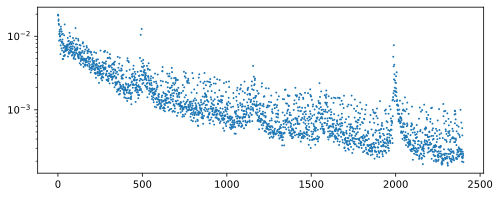

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.24
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.16
nca_out: (8, 32, 32) torch.float32, min=-0.62, max=1.12, mean=0.04, std=0.18


,,,,,,,
,,,,,,,
,,,,,,,

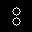
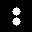
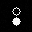
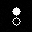
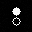
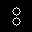
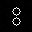
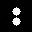
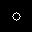
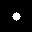
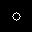
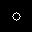
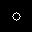
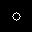
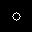
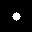
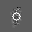
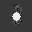
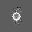
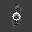
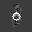
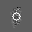
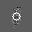
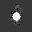

#0,#1,#2,#3,#4,#5,#6,#7

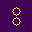
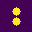
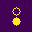
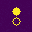
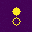
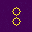
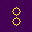
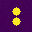

'./checkpoints/ncpu_AND_positional.pth.pth'

In [3]:
stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint("AND_positional.pth", steps=False, timestamp=False)

# Learning Information Propagation

In [9]:
# load seed model
trainer.load_checkpoint("ncpu_AND_positional.pth")

loss=0.000116:  18%|#8        | 1800/10000 [16:14<54:29,  2.51it/s]

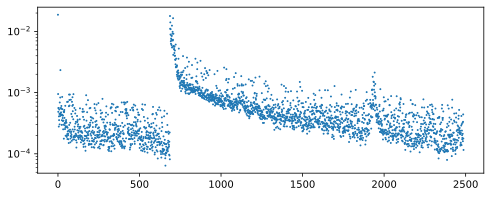

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.24
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.15
nca_out: (8, 32, 32) torch.float32, min=-0.36, max=1.17, mean=0.03, std=0.16


,,,,,,,
,,,,,,,
,,,,,,,

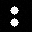
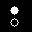
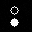
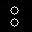
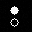
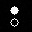
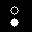
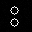
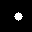
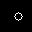
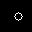
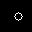
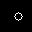
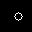
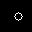
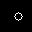
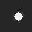
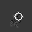
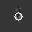
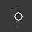
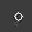
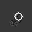
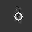
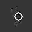

#0,#1,#2,#3,#4,#5,#6,#7

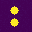
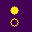
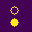
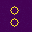
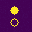
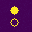
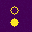
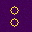

KeyboardInterrupt: 

In [12]:
stop_loss = 0.0001
N_evolutions = 5
STEPS = 2000
if trainer.ds.counter < STEPS * BATCH_SIZE:
    trainer.ds.counter = STEPS * BATCH_SIZE
trainer.ds.steps = STEPS * BATCH_SIZE
pbar = tqdm(range(STEPS * N_evolutions))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

In [8]:

trainer.save_checkpoint("AND_propagated_5.pth", steps=False, timestamp=False)

'./checkpoints/ncpu_AND_propagated_5.pth.pth'

In [9]:
# load seed model
trainer.load_checkpoint("ncpu_AND_propagated_5.pth")

loss=0.001568:  14%|#4        | 2900/20000 [27:03<2:26:10,  1.95it/s]

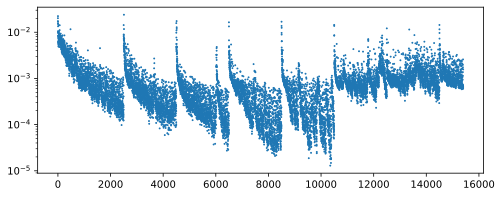

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.26
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.15
nca_out: (8, 32, 32) torch.float32, min=-0.19, max=1.11, mean=0.10, std=0.25


,,,,,,,
,,,,,,,
,,,,,,,

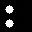
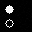
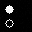
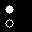
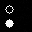
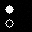
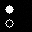
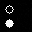
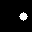
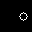
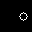
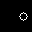
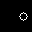
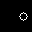
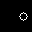
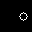
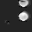
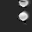
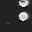
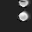
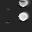
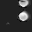
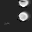
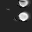

#0,#1,#2,#3,#4,#5,#6,#7

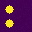
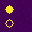
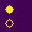
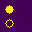
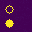
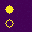
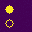
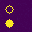

In [ ]:
stop_loss = 0.0001
STEPS = 2000
pbar = tqdm(range(STEPS*10))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint("AND_checkpoint_final.pth", steps=False, timestamp=False)

loss=0.000567:   0%|          | 0/1 [00:00<?, ?it/s]

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.04, mean=0.07, std=0.25
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.15
nca_out: (8, 32, 32) torch.float32, min=-0.42, max=1.07, mean=0.05, std=0.21


,,,,,,,
,,,,,,,
,,,,,,,

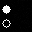
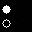
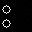
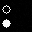
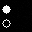
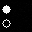
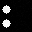
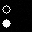
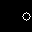
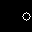
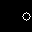
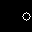
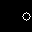
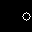
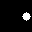
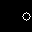
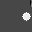
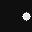
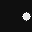
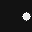
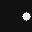
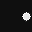
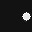
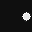

#0,#1,#2,#3,#4,#5,#6,#7

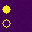
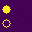
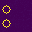
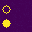
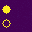
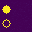
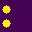
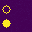

In [13]:
stop_loss = 0.0001
pbar = tqdm(range(1))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    clear_output(wait=False)
    display(pbar.container)

    trainer.display_optim_step(info)
